## Notebook Overview

This notebook implements the Baseline Model (Random Forest) and the Primary Model (Topographically Aware U-Net) for semantic segmentation of structural damage following the January 2025 Palisades Fire event. The preprocessing pipeline in `01_data_preprocessing.ipynb` has already constructed the multi-channel feature tensor and binary target mask.

### What Was Done in `01_data_preprocessing.ipynb`

The preprocessing notebook completed the following steps:

1. **Satellite Imagery**: Queried the Element 84 Earth Search STAC API to retrieve Sentinel-2 Level-2A surface reflectance imagery for pre-fire (December 2024 - January 6, 2025) and post-fire (February 2025) temporal windows.

2. **Cloud Masking**: Applied the Sentinel-2 Scene Classification Layer (SCL) to mask clouds, cloud shadows, and saturated pixels using valid class codes [2, 4, 5, 6, 7, 11].

3. **Spectral Index Calculation**: Computed the Normalized Burn Ratio (NBR) for both pre-fire and post-fire scenes using the formula:
   - `NBR = (NIR - SWIR) / (NIR + SWIR)`
   - `dNBR = NBR_pre - NBR_post` (positive values indicate burn damage)

4. **Topographic Data Processing**: Retrieved USGS 3DEP 10m Digital Elevation Model via Planetary Computer STAC API, mosaicked overlapping tiles, and derived the Aspect array (normalized to 0-1 range) to address topographic shadow artifacts in north-facing slopes during winter sun angles.

5. **Vector Data Ingestion**: Loaded three critical vector datasets:
   - **NIFC Fire Perimeter**: Defines the Area of Interest (AOI) boundary
   - **Microsoft Building Footprints**: Provides WUI infrastructure context as a feature channel
   - **CAL FIRE DINS Points**: Field inspection points identifying damaged structures

6. **Feature-Label Independence Design**: Labels were constructed directly from buffered DINS inspection points (15m buffer for GPS drift), NOT from building footprint geometries. This ensures the Building Footprints feature channel remains statistically independent from the target labels, preventing trivial correlation where y=1 would always imply building=1.

7. **Rasterization**: Converted all vector geometries to raster arrays matching the Sentinel-2 20m grid (UTM Zone 11N, EPSG:32611).

8. **Target Mask Construction**: Created the binary target mask using a Boolean union of:
   - Localized Otsu threshold on dNBR within the fire perimeter (vegetation burn mask)
   - Rasterized DINS damage zones (structural damage mask)

9. **Feature Tensor Stacking**: Assembled the 4-channel feature tensor:
   - **Channel 0**: Delta Normalized Burn Ratio (dNBR)
   - **Channel 1**: Post-Fire Shortwave-Infrared (SWIR), normalized 0-1
   - **Channel 2**: DEM-derived Aspect, normalized 0-1
   - **Channel 3**: Building Footprints, binary (0 or 1)

10. **Data Export**: Saved the following NumPy arrays to `final_project_files/model/`:
    - `X_tensor.npy`: Feature tensor with shape (height, width, 4)
    - `y_target.npy`: Boolean union target mask (vegetation burn + DINS damage)
    - `damaged_raster.npy`: DINS-only structural damage labels (used for this notebook)
    - `aoi_mask.npy`: Fire perimeter binary mask
    - `preprocessing_metadata.json`: Complete metadata for reproducibility

## Methodology for Feature-Label Independence

### Ground Truth

Labels are derived from buffered CAL FIRE DINS inspection points (15m buffer for GPS drift). This approach deliberately avoids joining DINS points to building footprint geometries before rasterization.

### Feature-Label Independence Verified

The preprocessing pipeline confirmed statistical independence between the Building Footprints feature channel and the target labels:

- **Pearson Correlation**: 0.19 (if labels were footprint-derived, this would be ~0.90+)
- **Overlap Percentage**: 38.3% (if labels were footprint-derived, this would be 100%)

This decoupling ensures the model must learn genuine predictive relationships between spectral signatures, topographic context, and infrastructure presence to predict field-verified damage outcomes.

### Spatial K-Fold Cross-Validation

Instead of a single train/validation/test split vulnerable to random variation, this implementation uses 5-Fold Spatial Cross-Validation at the block level. Each fold uses 60% of blocks for training, 20% for validation, and 20% for testing, with all blocks appearing in the test set exactly once across the 5 folds.

### Patch-Block Alignment

Block size equals patch size (64x64 pixels). Each extracted patch corresponds exactly to one spatial block, eliminating spatial leakage where pixels from training blocks could appear in validation/test patches.

## Environment Setup and Dependencies

In [1]:
# COLAB DRIVE MOUNT
# Uncomment if running in Google Colab.
from google.colab import drive
drive.mount("/content/drive")
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks")

Mounted at /content/drive


In [2]:
# CORE LIBRARIES
import os
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# MACHINE LEARNING LIBRARIES
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, jaccard_score, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import joblib

# DEEP LEARNING LIBRARIES
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dropout, concatenate,
    Conv2DTranspose, BatchNormalization, Activation
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryFocalCrossentropy
from tensorflow.keras import backend as K

In [3]:
# CONFIGURE DISPLAY AND OUTPUT PATHS
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

# SUPPRESS WARNINGS FOR CLEANER OUTPUT
warnings.filterwarnings("ignore")

# CREATE OUTPUT DIRECTORIES
model_path = Path("final_project_files/model")
model_path.mkdir(parents = True, exist_ok = True)

images_path = Path("final_project_files/images")
images_path.mkdir(parents = True, exist_ok = True)

# SET RANDOM SEED FOR REPRODUCIBILITY
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

## Load Preprocessed Data

### Critical Variables from Preprocessing

The following variables are loaded from the preprocessing pipeline and must be understood for seamless integration:

| Variable | Shape | Description |
|----------|-------|-------------|
| `X_tensor` | (height, width, 4) | Multi-channel feature tensor. Channel order: [dNBR, Post-Fire SWIR, DEM Aspect, Building Footprints] |
| `y_target` | (height, width) | Binary target mask from DINS-only labels (point-based buffering) |
| `aoi_mask` | (height, width) | Binary mask indicating pixels inside the fire perimeter AOI |

### Tensor Specs

- **Spatial Resolution**: 20 meters per pixel
- **Coordinate Reference System**: EPSG:32611 (UTM Zone 11N)
- **Raster Dimensions**: Approximately 787 rows x 1255 columns (varies with exact AOI clipping)
- **Data Type**: float32 for features, uint8 for masks

In [4]:
# LOAD FEATURE TENSOR AND TARGET MASK
X_tensor = np.load(model_path / "X_tensor.npy")
aoi_mask = np.load(model_path / "aoi_mask.npy")

# LOAD DINS-ONLY TARGET MASK
# Using damaged_raster.npy which contains point-based DINS labels.
y_target = np.load(model_path / "damaged_raster.npy")

print(f"X_tensor Shape: {X_tensor.shape}")
print(f"y_target Shape: {y_target.shape}")
print(f"AOI Mask Shape: {aoi_mask.shape}")

X_tensor Shape: (801, 1173, 4)
y_target Shape: (801, 1173)
AOI Mask Shape: (801, 1173)


In [5]:
# VERIFY TENSOR DIMENSIONS
height, width, channels = X_tensor.shape

assert X_tensor.shape[2] == 4, "Feature tensor should have 4 channels."
assert y_target.shape == (height, width), "Target mask shape mismatch."
assert aoi_mask.shape == (height, width), "AOI mask shape mismatch."

# CHANNEL NAMES CORRESPOND TO PREPROCESSING TENSOR STACK ORDER
channel_names = ["dNBR", "Post-Fire SWIR", "DEM Aspect", "Building Footprints"]

print(f"Image Dimensions: {height} x {width}")
print(f"Feature Channels: {channels}")

Image Dimensions: 801 x 1173
Feature Channels: 4


In [6]:
# QUANTIFY CLASS IMBALANCE
# With point-based DINS labels, imbalance characteristics differ from footprint-based.
total_pixels = y_target.size
aoi_pixels = np.sum(aoi_mask == 1)

# Calculate imbalance ratio within AOI only.
y_target_aoi = y_target[aoi_mask == 1]
damaged_in_aoi = np.sum(y_target_aoi == 1)
intact_in_aoi = np.sum(y_target_aoi == 0)
imbalance_ratio = intact_in_aoi / max(damaged_in_aoi, 1)

print(f"Total Pixels: {total_pixels:,}")
print(f"Pixels Inside AOI: {aoi_pixels:,}")
print(f"Damaged Pixels (Class 1): {damaged_in_aoi:,} ({damaged_in_aoi / aoi_pixels * 100:.2f}% of AOI)")
print(f"Intact Pixels (Class 0): {intact_in_aoi:,} ({intact_in_aoi / aoi_pixels * 100:.2f}% of AOI)")
print(f"Class Imbalance Ratio: {imbalance_ratio:.1f}:1")

Total Pixels: 939,573
Pixels Inside AOI: 243,261
Damaged Pixels (Class 1): 9,826 (4.04% of AOI)
Intact Pixels (Class 0): 233,435 (95.96% of AOI)
Class Imbalance Ratio: 23.8:1


## Spatial K-Fold Cross-Validation

### Theoretical Background

**Why Spatial Cross-Validation?**

Traditional random train/test splits violate the assumption of independence for geospatial data and adjacent pixels are spatially autocorrelated. If training and test pixels are spatially adjacent, the model can achieve artificially high performance by interpolating between known neighbors rather than learning generalizable patterns.

**Block-Based Stratification**

The image is divided into non-overlapping 64x64 pixel blocks. Each block is assigned to exactly one of 5 folds. Blocks containing damaged structures are stratified to ensure each fold has a representative proportion of the minority class. This prevents situations where one fold contains all the damage and others contain none.

**K-Fold Rotation**

For each of the 5 iterations:
- 1 fold serves as the test set (20% of blocks)
- 1 fold serves as the validation set (20% of blocks)
- 3 folds serve as the training set (60% of blocks)

This rotation ensures every block appears in the test set exactly once across the 5 folds, providing robust metric estimates with confidence intervals.

### Why 64x64 Blocks?

The block size of 64x64 pixels was chosen to:
1. Match the U-Net input patch size, ensuring patch-block alignment
2. Provide sufficient spatial context for the convolutional encoder (3 pooling layers: 64 -> 32 -> 16 -> 8)
3. Balance between too-small blocks (insufficient context) and too-large blocks (too few blocks for stratification)

In [7]:
# DEFINE SPATIAL BLOCK PARAMETERS
# Block size determines granularity of spatial stratification.
# Value MUST equal patch_size for U-Net to eliminate spatial leakage.
block_size = 64
n_folds = 5

# Calculate number of blocks in each dimension.
n_blocks_y = int(np.ceil(height / block_size))
n_blocks_x = int(np.ceil(width / block_size))
total_blocks = n_blocks_y * n_blocks_x

print(f"Block Size: {block_size} x {block_size} pixels")
print(f"Grid Dimensions: {n_blocks_y} rows x {n_blocks_x} columns")
print(f"Total Blocks: {total_blocks}")
print(f"Number of Folds: {n_folds}")

Block Size: 64 x 64 pixels
Grid Dimensions: 13 rows x 19 columns
Total Blocks: 247
Number of Folds: 5


In [8]:
# ASSIGN EACH PIXEL TO A SPATIAL BLOCK
# Block indices are computed based on pixel coordinates.
y_indices, x_indices = np.meshgrid(
    np.arange(height),
    np.arange(width),
    indexing = "ij"
)

# Calculate block assignment for each pixel.
block_y = y_indices // block_size
block_x = x_indices // block_size
block_ids = block_y * n_blocks_x + block_x

print(f"Block ID Array Shape: {block_ids.shape}")
print(f"Block ID Range: [{block_ids.min()}, {block_ids.max()}]")

Block ID Array Shape: (801, 1173)
Block ID Range: [0, 246]


In [9]:
# COMPUTE DAMAGE PIXEL COUNT PER BLOCK
# Required for stratified fold assignment.
unique_blocks = np.unique(block_ids)
block_damage_counts = {}
block_aoi_counts = {}

for block_id in unique_blocks:
    block_mask = block_ids == block_id
    block_aoi = aoi_mask[block_mask]
    block_labels = y_target[block_mask]

    # Count damaged pixels within the block that are inside AOI.
    damaged_in_block = np.sum((block_labels == 1) & (block_aoi == 1))
    aoi_in_block = np.sum(block_aoi == 1)

    block_damage_counts[block_id] = damaged_in_block
    block_aoi_counts[block_id] = aoi_in_block

# Separate blocks with and without damaged structures.
blocks_with_damage = [(b, count) for b, count in block_damage_counts.items() if count > 0]
blocks_without_damage = [b for b, count in block_damage_counts.items() if count == 0]

total_damage_pixels = sum([count for _, count in blocks_with_damage])

print(f"Blocks with Damaged Structures: {len(blocks_with_damage)}")
print(f"Blocks without Damaged Structures: {len(blocks_without_damage)}")
print(f"Total Damaged Pixels: {total_damage_pixels:,}")

Blocks with Damaged Structures: 50
Blocks without Damaged Structures: 197
Total Damaged Pixels: 9,826


In [10]:
# CREATE STRATIFIED K-FOLD ASSIGNMENTS
# Blocks with damage are distributed evenly across folds.
np.random.seed(random_seed)

# Create arrays for fold assignment.
all_blocks = list(unique_blocks)
block_has_damage = np.array([1 if block_damage_counts[b] > 0 else 0 for b in all_blocks])

# Use StratifiedKFold to ensure damage blocks are distributed across folds.
skf = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = random_seed)

# Store fold assignments.
block_to_fold = {}
fold_blocks = {fold: [] for fold in range(n_folds)}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(all_blocks, block_has_damage)):
    for idx in test_idx:
        block_id = all_blocks[idx]
        block_to_fold[block_id] = fold_idx
        fold_blocks[fold_idx].append(block_id)

# Verify distribution.
for fold in range(n_folds):
    fold_damage_blocks = sum([1 for b in fold_blocks[fold] if block_damage_counts[b] > 0])
    fold_damage_pixels = sum([block_damage_counts[b] for b in fold_blocks[fold]])
    print(f"Fold {fold + 1}: {len(fold_blocks[fold])} blocks, {fold_damage_blocks} with damage, {fold_damage_pixels:,} damage pixels")

Fold 1: 50 blocks, 10 with damage, 1,523 damage pixels
Fold 2: 50 blocks, 10 with damage, 623 damage pixels
Fold 3: 49 blocks, 10 with damage, 3,380 damage pixels
Fold 4: 49 blocks, 10 with damage, 1,486 damage pixels
Fold 5: 49 blocks, 10 with damage, 2,814 damage pixels


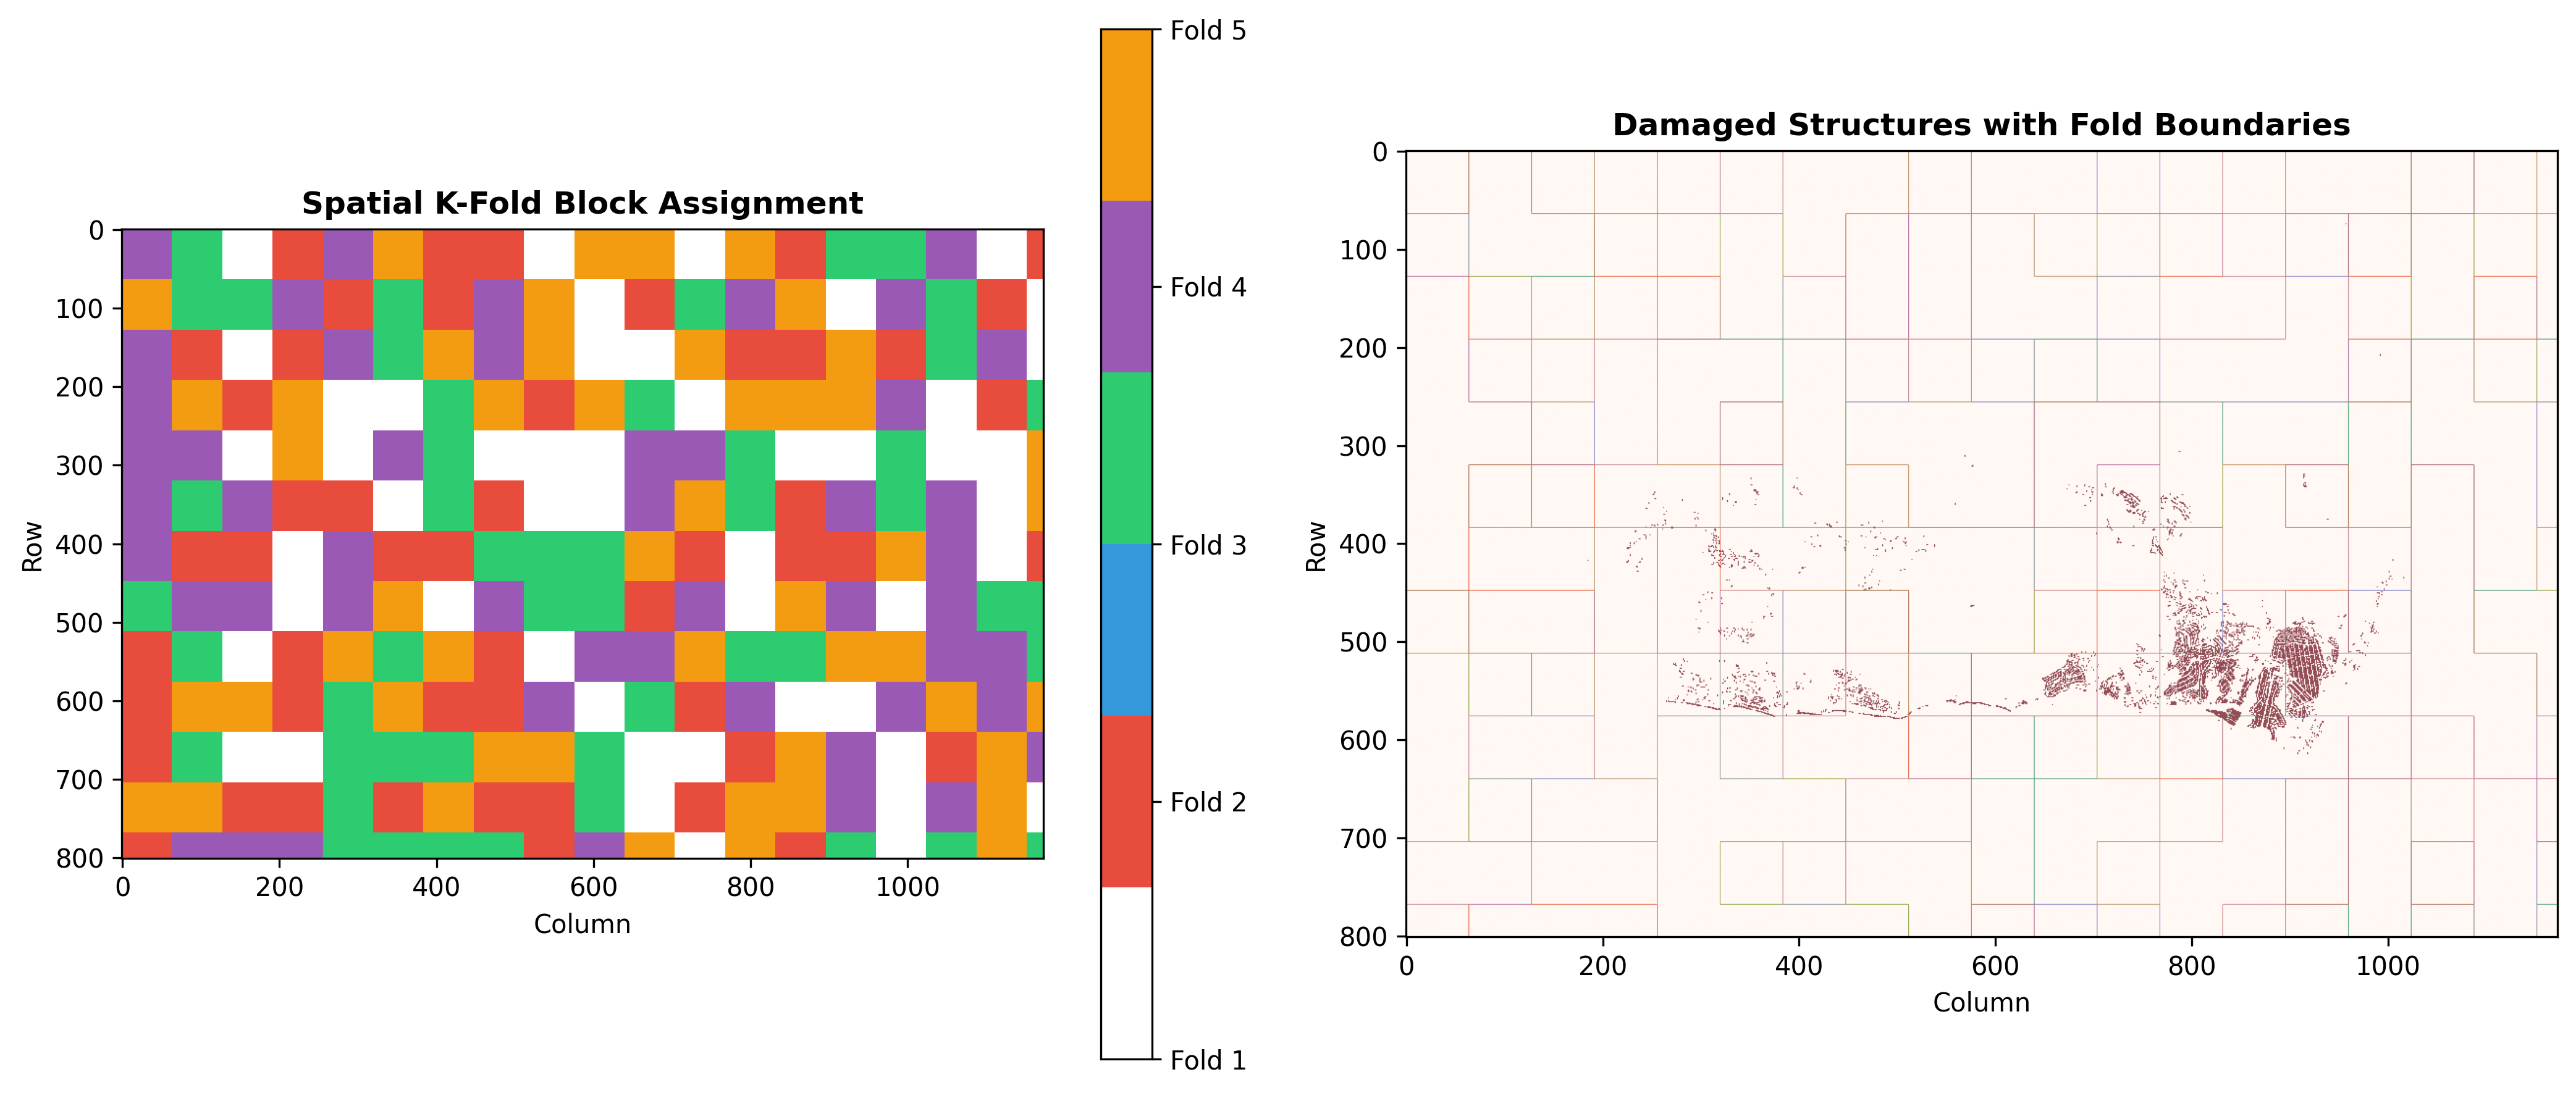

In [36]:
# VISUALIZE FOLD DISTRIBUTION
height, width, _ = X_tensor.shape
fold_visualization = np.zeros((height, width), dtype = np.uint8)

for block_id, fold in block_to_fold.items():
    fold_visualization[block_ids == block_id] = fold + 1

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# Fold assignments.
cmap_folds = plt.cm.colors.ListedColormap(["white", "#E74C3C", "#3498DB", "#2ECC71", "#9B59B6", "#F39C12"])
im1 = axes[0].imshow(fold_visualization, cmap = cmap_folds, interpolation = "nearest")
axes[0].set_title("Spatial K-Fold Block Assignment", fontsize = 12, fontweight = "bold")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
cbar1 = plt.colorbar(im1, ax = axes[0], ticks = range(n_folds + 1))
cbar1.set_ticklabels(["Outside"] + [f"Fold {i+1}" for i in range(n_folds)])

# Target mask with fold overlay.
axes[1].imshow(y_target, cmap = "Reds", alpha = 0.7)
for fold in range(n_folds):
    axes[1].contour(fold_visualization == fold + 1, colors = plt.cm.tab10(fold), linewidths = 0.3, alpha = 0.5)
axes[1].set_title("Damaged Structures with Fold Boundaries", fontsize = 12, fontweight = "bold")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")

plt.tight_layout()
plt.savefig(images_path / "spatial_kfold_distribution.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [12]:
def get_fold_masks(test_fold, block_ids, block_to_fold, aoi_mask, n_folds):
    """
    Generate train/val/test masks for a given test fold.

    Parameters:
        test_fold: Index of the fold to use as test set (0 to n_folds-1).
        block_ids: 2D array mapping pixels to block IDs.
        block_to_fold: Dictionary mapping block_id to fold index.
        aoi_mask: 2D boolean array indicating valid AOI pixels.
        n_folds: Total number of folds.

    Returns:
        train_mask_aoi: Boolean mask for training pixels within AOI.
        val_mask_aoi: Boolean mask for validation pixels within AOI.
        test_mask_aoi: Boolean mask for test pixels within AOI.
        train_blocks: Set of block IDs in training set.
        val_blocks: Set of block IDs in validation set.
        test_blocks: Set of block IDs in test set.
    """
    # Validation fold is the one immediately before test (wrapping around).
    val_fold = (test_fold - 1) % n_folds

    # Training folds are all others.
    train_folds = [f for f in range(n_folds) if f != test_fold and f != val_fold]

    # Assign blocks to sets.
    train_blocks = set()
    val_blocks = set()
    test_blocks = set()

    for block_id, fold in block_to_fold.items():
        if fold == test_fold:
            test_blocks.add(block_id)
        elif fold == val_fold:
            val_blocks.add(block_id)
        else:
            train_blocks.add(block_id)

    # Create pixel-level masks.
    train_mask = np.zeros_like(aoi_mask, dtype = bool)
    val_mask = np.zeros_like(aoi_mask, dtype = bool)
    test_mask = np.zeros_like(aoi_mask, dtype = bool)

    for block_id in train_blocks:
        train_mask[block_ids == block_id] = True
    for block_id in val_blocks:
        val_mask[block_ids == block_id] = True
    for block_id in test_blocks:
        test_mask[block_ids == block_id] = True

    # Apply AOI constraint.
    train_mask_aoi = train_mask & (aoi_mask == 1)
    val_mask_aoi = val_mask & (aoi_mask == 1)
    test_mask_aoi = test_mask & (aoi_mask == 1)

    return train_mask_aoi, val_mask_aoi, test_mask_aoi, train_blocks, val_blocks, test_blocks

In [13]:
# VERIFY FOLD BALANCE
for test_fold in range(n_folds):
    train_mask_aoi, val_mask_aoi, test_mask_aoi, _, _, _ = get_fold_masks(
        test_fold, block_ids, block_to_fold, aoi_mask, n_folds
    )

    train_damage = np.sum(y_target[train_mask_aoi] == 1)
    val_damage = np.sum(y_target[val_mask_aoi] == 1)
    test_damage = np.sum(y_target[test_mask_aoi] == 1)

    train_total = np.sum(train_mask_aoi)
    val_total = np.sum(val_mask_aoi)
    test_total = np.sum(test_mask_aoi)

    print(f"Fold {test_fold + 1} as Test:")
    print(f"  Train: {train_damage:,} damage / {train_total:,} total ({train_damage / max(train_total, 1) * 100:.2f}%)")
    print(f"  Val:   {val_damage:,} damage / {val_total:,} total ({val_damage / max(val_total, 1) * 100:.2f}%)")
    print(f"  Test:  {test_damage:,} damage / {test_total:,} total ({test_damage / max(test_total, 1) * 100:.2f}%)")
    print()

Fold 1 as Test:
  Train: 5,489 damage / 141,772 total (3.87%)
  Val:   2,814 damage / 52,113 total (5.40%)
  Test:  1,523 damage / 49,376 total (3.08%)

Fold 2 as Test:
  Train: 7,680 damage / 141,898 total (5.41%)
  Val:   1,523 damage / 49,376 total (3.08%)
  Test:  623 damage / 51,987 total (1.20%)

Fold 3 as Test:
  Train: 5,823 damage / 147,386 total (3.95%)
  Val:   623 damage / 51,987 total (1.20%)
  Test:  3,380 damage / 43,888 total (7.70%)

Fold 4 as Test:
  Train: 4,960 damage / 153,476 total (3.23%)
  Val:   3,380 damage / 43,888 total (7.70%)
  Test:  1,486 damage / 45,897 total (3.24%)

Fold 5 as Test:
  Train: 5,526 damage / 145,251 total (3.80%)
  Val:   1,486 damage / 45,897 total (3.24%)
  Test:  2,814 damage / 52,113 total (5.40%)



## Baseline Model: Random Forest with Spatial K-Fold CV

The Random Forest classifier is trained and evaluated using 5-fold spatial cross-validation. Each fold trains on 60% of blocks (3 folds), validates on 20% (1 fold), and tests on 20% (1 fold). Final metrics are reported as mean ± standard deviation across the 5 test folds.

In [14]:
# RANDOM FOREST K-FOLD CROSS-VALIDATION
rf_fold_results = {
    "f1_train": [],
    "f1_val": [],
    "f1_test": [],
    "iou_train": [],
    "iou_val": [],
    "iou_test": [],
    "feature_importance": []
}

for fold in range(n_folds):
    print(f"FOLD {fold + 1}/{n_folds}")

    # Get fold masks.
    train_mask_aoi, val_mask_aoi, test_mask_aoi, _, _, _ = get_fold_masks(
        fold, block_ids, block_to_fold, aoi_mask, n_folds
    )

    # Extract pixel data.
    X_train_rf = np.nan_to_num(X_tensor[train_mask_aoi], nan = 0.0)
    y_train_rf = y_target[train_mask_aoi]
    X_val_rf = np.nan_to_num(X_tensor[val_mask_aoi], nan = 0.0)
    y_val_rf = y_target[val_mask_aoi]
    X_test_rf = np.nan_to_num(X_tensor[test_mask_aoi], nan = 0.0)
    y_test_rf = y_target[test_mask_aoi]

    print(f"  Train: {X_train_rf.shape[0]:,} pixels | Val: {X_val_rf.shape[0]:,} | Test: {X_test_rf.shape[0]:,}")

    # Train Random Forest.
    rf_classifier = RandomForestClassifier(
        n_estimators = 100,
        max_depth = 15,
        min_samples_split = 5,
        min_samples_leaf = 2,
        class_weight = "balanced",
        random_state = random_seed,
        n_jobs = -1,
        verbose = 0
    )
    rf_classifier.fit(X_train_rf, y_train_rf)

    # Predict on all splits.
    y_pred_train = rf_classifier.predict(X_train_rf)
    y_pred_val = rf_classifier.predict(X_val_rf)
    y_pred_test = rf_classifier.predict(X_test_rf)

    # Calculate metrics.
    f1_train = f1_score(y_train_rf, y_pred_train, average = "binary", zero_division = 0)
    f1_val = f1_score(y_val_rf, y_pred_val, average = "binary", zero_division = 0)
    f1_test = f1_score(y_test_rf, y_pred_test, average = "binary", zero_division = 0)

    iou_train = jaccard_score(y_train_rf, y_pred_train, average = "binary", zero_division = 0)
    iou_val = jaccard_score(y_val_rf, y_pred_val, average = "binary", zero_division = 0)
    iou_test = jaccard_score(y_test_rf, y_pred_test, average = "binary", zero_division = 0)

    # Store results.
    rf_fold_results["f1_train"].append(f1_train)
    rf_fold_results["f1_val"].append(f1_val)
    rf_fold_results["f1_test"].append(f1_test)
    rf_fold_results["iou_train"].append(iou_train)
    rf_fold_results["iou_val"].append(iou_val)
    rf_fold_results["iou_test"].append(iou_test)
    rf_fold_results["feature_importance"].append(rf_classifier.feature_importances_)

    print(f"  Test F1: {f1_test:.4f} | Test IoU: {iou_test:.4f}")

FOLD 1/5
  Train: 141,772 pixels | Val: 52,113 | Test: 49,376
  Test F1: 0.2372 | Test IoU: 0.1346
FOLD 2/5
  Train: 141,898 pixels | Val: 49,376 | Test: 51,987
  Test F1: 0.1665 | Test IoU: 0.0908
FOLD 3/5
  Train: 147,386 pixels | Val: 51,987 | Test: 43,888
  Test F1: 0.4831 | Test IoU: 0.3185
FOLD 4/5
  Train: 153,476 pixels | Val: 43,888 | Test: 45,897
  Test F1: 0.3194 | Test IoU: 0.1900
FOLD 5/5
  Train: 145,251 pixels | Val: 45,897 | Test: 52,113
  Test F1: 0.3791 | Test IoU: 0.2339


In [15]:
# AGGREGATE RANDOM FOREST RESULTS
rf_f1_mean = np.mean(rf_fold_results["f1_test"])
rf_f1_std = np.std(rf_fold_results["f1_test"])
rf_iou_mean = np.mean(rf_fold_results["iou_test"])
rf_iou_std = np.std(rf_fold_results["iou_test"])

# Average feature importance across folds.
rf_feature_importance_mean = np.mean(rf_fold_results["feature_importance"], axis = 0)
rf_feature_importance_std = np.std(rf_fold_results["feature_importance"], axis = 0)

print("Test Set Metrics (mean +/- std)")
print(f"  F1 Score: {rf_f1_mean:.4f} +/- {rf_f1_std:.4f}")
print(f"  IoU:      {rf_iou_mean:.4f} +/- {rf_iou_std:.4f}")
print()
print("Feature Importance (mean +/- std)")
for idx, name in enumerate(channel_names):
    print(f"  {name}: {rf_feature_importance_mean[idx]:.4f} +/- {rf_feature_importance_std[idx]:.4f}")

Test Set Metrics (mean +/- std)
  F1 Score: 0.3171 +/- 0.1100
  IoU:      0.1936 +/- 0.0791

Feature Importance (mean +/- std)
  dNBR: 0.4579 +/- 0.0129
  Post-Fire SWIR: 0.2584 +/- 0.0144
  DEM Aspect: 0.1127 +/- 0.0084
  Building Footprints: 0.1711 +/- 0.0076


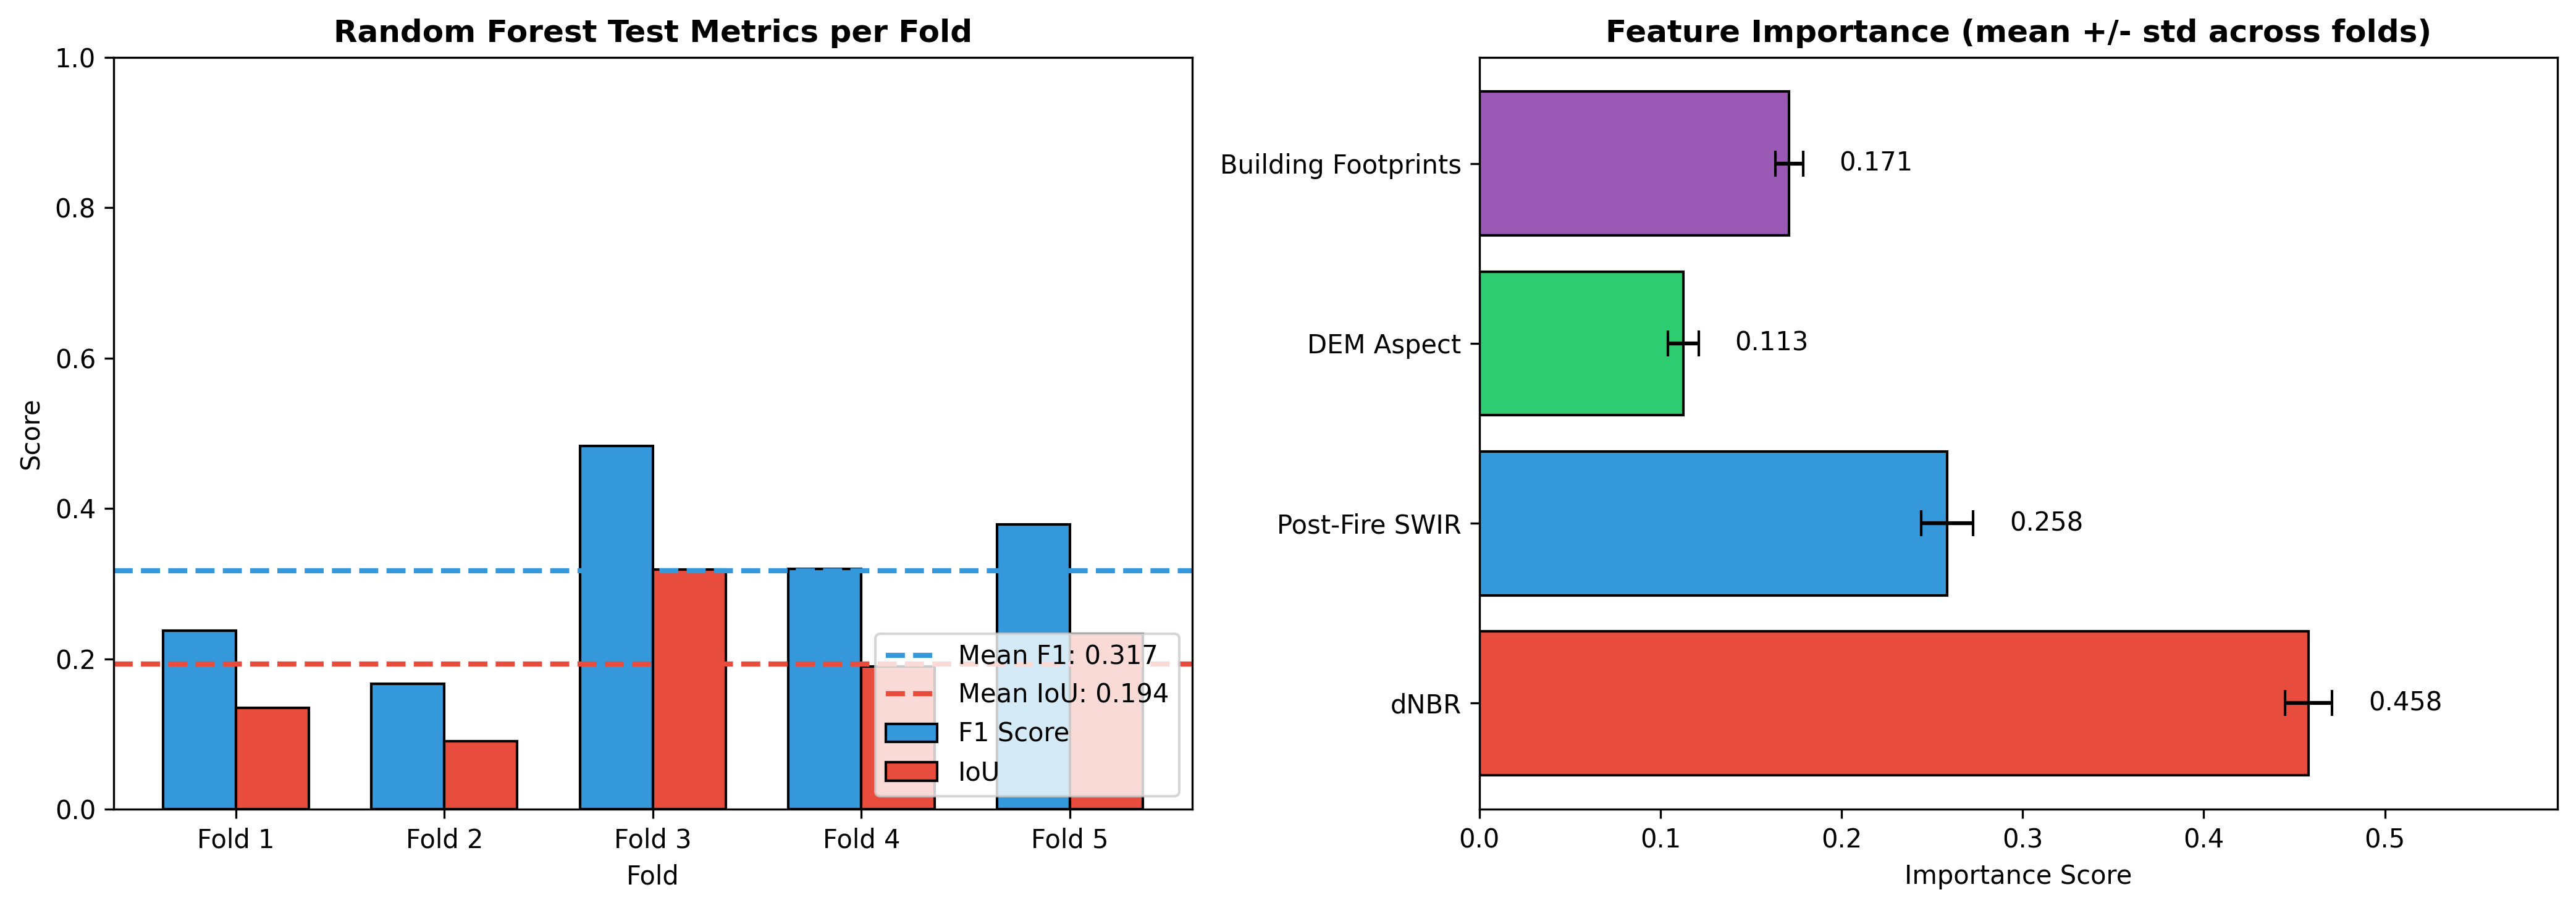

In [16]:
# VISUALIZE RANDOM FOREST K-FOLD RESULTS
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# F1 and IoU per fold.
fold_labels = [f"Fold {i+1}" for i in range(n_folds)]
x_pos = np.arange(n_folds)
width = 0.35

axes[0].bar(x_pos - width/2, rf_fold_results["f1_test"], width, label = "F1 Score", color = "#3498DB", edgecolor = "black")
axes[0].bar(x_pos + width/2, rf_fold_results["iou_test"], width, label = "IoU", color = "#E74C3C", edgecolor = "black")
axes[0].axhline(y = rf_f1_mean, color = "#3498DB", linestyle = "--", linewidth = 2, label = f"Mean F1: {rf_f1_mean:.3f}")
axes[0].axhline(y = rf_iou_mean, color = "#E74C3C", linestyle = "--", linewidth = 2, label = f"Mean IoU: {rf_iou_mean:.3f}")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Score")
axes[0].set_title("Random Forest Test Metrics per Fold", fontsize = 12, fontweight = "bold")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(fold_labels)
axes[0].legend(loc = "lower right")
axes[0].set_ylim(0, 1)

# Feature importance with error bars.
colors = ["#E74C3C", "#3498DB", "#2ECC71", "#9B59B6"]
axes[1].barh(channel_names, rf_feature_importance_mean, xerr = rf_feature_importance_std, color = colors, edgecolor = "black", capsize = 5)
axes[1].set_xlabel("Importance Score")
axes[1].set_title("Feature Importance (mean +/- std across folds)", fontsize = 12, fontweight = "bold")
axes[1].set_xlim(0, max(rf_feature_importance_mean) * 1.3)

# Add value labels.
for idx, (mean, std) in enumerate(zip(rf_feature_importance_mean, rf_feature_importance_std)):
    axes[1].text(mean + std + 0.02, idx, f"{mean:.3f}", va = "center", fontsize = 10)

plt.tight_layout()
plt.savefig(images_path / "rf_kfold_results.png", dpi = 300, bbox_inches = "tight")
plt.show()

## Primary Model: Topographically Aware U-Net with Spatial K-Fold CV

### Theoretical Background

The U-Net architecture enables precise localization while maintaining global context through skip connections. With patch-block alignment (64x64 patches matching 64x64 blocks), spatial leakage is eliminated.

### U-Net Architecture Overview

The U-Net consists of three main components:

1. **Encoder Path**: A series of convolutional blocks followed by max pooling operations that progressively reduce spatial resolution while increasing feature depth. This captures "what" is in the image.

2. **Bottleneck**: The deepest part of the network where the most abstract features are learned.

3. **Decoder Path**: A series of transposed convolutions (upsampling) that progressively restore spatial resolution. Skip connections concatenate encoder features with decoder features at matching resolutions, preserving fine-grained spatial information lost during pooling.

### Architectural Constraints for 64x64 Input

With a 64x64 input patch, the encoder can perform at most 3 pooling operations before the spatial dimensions become too small:
- **Level 1**: 64x64 -> 32x32 (after first pooling)
- **Level 2**: 32x32 -> 16x16 (after second pooling)
- **Level 3**: 16x16 -> 8x8 (after third pooling)
- **Bottleneck**: 8x8 (minimum viable spatial dimension)

The decoder mirrors this structure, upsampling back to 64x64.

### Loss Functions for Severe Class Imbalance

With class imbalance ratios exceeding 40:1, standard binary cross-entropy loss fails because the model can achieve high accuracy by predicting the majority class (intact) for all pixels. Two specialized loss functions address this:

1. **Dice Loss**: Directly optimizes the F1-Score (Dice Coefficient), the harmonic mean of precision and recall. It treats false positives and false negatives equally, making it robust to class imbalance.

2. **Focal Loss**: Down-weights easy-to-classify background pixels by applying a focusing parameter (gamma) that reduces the contribution of confident predictions. This focuses learning on hard-to-classify minority pixels.

**Combined Loss**: A weighted sum of Dice Loss and Focal Loss provides both direct metric optimization and focused attention on minority class examples.

### Helpful TensorFlow/Keras Functions

For U-Net implementation, consider using:
- `tf.keras.layers.Input()` - Define input tensor shape
- `tf.keras.layers.Conv2D()` - 2D convolutional layer with kernel_size, filters, padding, activation
- `tf.keras.layers.MaxPooling2D()` - Downsampling via max pooling
- `tf.keras.layers.Conv2DTranspose()` - Transposed convolution for upsampling
- `tf.keras.layers.concatenate()` - Concatenate skip connection tensors
- `tf.keras.layers.BatchNormalization()` - Normalize activations for stable training
- `tf.keras.layers.Dropout()` - Regularization to prevent overfitting
- `tf.keras.layers.Activation()` - Apply activation function
- `tf.keras.Model()` - Functional API model constructor
- `tf.keras.backend.flatten()` - Flatten tensor for loss computation
- `tf.keras.backend.sum()` - Sum tensor elements
- `tf.keras.backend.cast()` - Cast tensor dtype
- `tf.keras.losses.BinaryFocalCrossentropy()` - Built-in focal loss
- `tf.keras.callbacks.EarlyStopping()` - Stop training when validation loss plateaus
- `tf.keras.callbacks.ReduceLROnPlateau()` - Reduce learning rate on plateau

### Define Custom Loss Functions

Implement the Dice Loss and Combined Loss functions.

In [17]:
# IMPLEMENT DICE LOSS FUNCTION
# The Dice Loss directly optimizes F1-Score (Dice Coefficient) for binary segmentation.
# Formula: Dice = 2 * |A ∩ B| / (|A| + |B|)
# Dice Loss = 1 - Dice Coefficient

# Define function signature with y_true, y_pred, and smooth parameter.
# Flatten both tensors using K.flatten().
# Compute intersection = K.sum(y_true_flat * y_pred_flat).
# Compute union = K.sum(y_true_flat) + K.sum(y_pred_flat).
# Return 1.0 - (2.0 * intersection + smooth) / (union + smooth).

pass # Replace.

In [18]:
# TODO: IMPLEMENT COMBINED LOSS FUNCTION
# Uses built-in BinaryFocalCrossentropy from Keras.
# Combines Dice Loss (metric optimization) with Focal Loss (minority class focus).

# Instantiate focal_loss_fn = BinaryFocalCrossentropy(...).
# Parameters: apply_class_balancing=True, alpha=0.80, gamma=2.0, from_logits=False.
# Define combined_loss function with y_true, y_pred, dice_weight=0.5, focal_weight=0.5.
# Compute dice_component = dice_loss(y_true, y_pred).
# Compute focal_component = focal_loss_fn(y_true, y_pred).
# Return dice_weight * dice_component + focal_weight * focal_component.

pass # Replace.

### Define Custom Metrics

Implement Dice Coefficient and IoU as Keras-compatible metrics.

In [19]:
# IMPLEMENT DICE COEFFICIENT METRIC
# Tracks Dice score during training (same formula as loss but returns coefficient).

# Define function with y_true, y_pred, smooth=1e-6.
# Flatten tensors.
# Compute intersection and union.
# Return (2 * intersection + smooth) / (union + smooth).

pass # Replace.

In [20]:
# IMPLEMENT IOU METRIC
# Tracks Intersection over Union (Jaccard Index) during training.
# IoU = |A ∩ B| / |A ∪ B| = intersection / (A + B - intersection)

# Define function with y_true, y_pred, threshold=0.5.
# Binarize predictions using threshold.
# Flatten tensors.
# Compute intersection.
# Compute union = sum(y_true) + sum(y_pred_binary) - intersection.
# Return (intersection + smooth) / (union + smooth).

pass # Replace.

### Define U-Net Architecture

Build the U-Net architecture optimized for 64x64 input patches.

**Architecture Specs**:
- **Input shape**: (64, 64, 4) - 4 channels from feature tensor
- **Base filters**: 32 (doubles at each encoder level)
- **Encoder levels**: 3 (64 -> 32 -> 16 -> 8)
- **Bottleneck**: 8x8 spatial resolution
- **Decoder levels**: 3 (8 -> 16 -> 32 -> 64)
- **Output**: Single channel with sigmoid activation (binary segmentation)

In [21]:
# IMPLEMENT CONVOLUTIONAL BLOCK HELPER FUNCTION
# Creates a reusable block: Conv2D -> BatchNorm -> ReLU -> Conv2D -> BatchNorm -> ReLU -> Dropout.

# Define function conv_block(inputs, filters, kernel_size=3, dropout_rate=0.1).
# Apply Conv2D(filters, kernel_size, padding="same", kernel_initializer="he_normal").
# Apply BatchNormalization().
# Apply Activation("relu").
# Repeat Conv2D -> BatchNorm -> Activation for second convolution.
# If dropout_rate > 0, apply Dropout(dropout_rate).
# Return output tensor.

pass # Replace.

In [22]:
# IMPLEMENT U-NET ARCHITECTURE FUNCTION
# Build U-Net optimized for 64x64 input with 3 encoder/decoder levels.
# Encoder: 64 -> 32 -> 16 -> 8, Decoder: 8 -> 16 -> 32 -> 64.

# Define function build_unet_64(input_shape, num_classes=1, base_filters=32).
# Create Input layer: inputs = Input(shape=input_shape).

# ENCODER PATH (use increasing dropout: 0.1, 0.1, 0.2):
# enc1 = conv_block(inputs, base_filters, dropout_rate=0.1).
# pool1 = MaxPooling2D(pool_size=(2, 2))(enc1).
# enc2 = conv_block(pool1, base_filters*2, dropout_rate=0.1).
# pool2 = MaxPooling2D(pool_size=(2, 2))(enc2).
# enc3 = conv_block(pool2, base_filters*4, dropout_rate=0.2).
# pool3 = MaxPooling2D(pool_size=(2, 2))(enc3).

# BOTTLENECK (highest dropout for regularization):
# bottleneck = conv_block(pool3, base_filters*8, dropout_rate=0.3).

# DECODER PATH (use matching dropout to encoder: 0.2, 0.1, 0.1):
# up3 = Conv2DTranspose(base_filters*4, (2,2), strides=(2,2), padding="same")(bottleneck).
# up3 = concatenate([up3, enc3]).
# dec3 = conv_block(up3, base_filters*4, dropout_rate=0.2).
# up2 = Conv2DTranspose(...)(dec3), concatenate with enc2, conv_block -> dec2.
# up1 = Conv2DTranspose(...)(dec2), concatenate with enc1, conv_block -> dec1.

# OUTPUT LAYER:
# outputs = Conv2D(num_classes, (1,1), activation="sigmoid")(dec1).
# model = Model(inputs=inputs, outputs=outputs, name="TopographicallyAwareUNet_64").
# Return model.

pass # Replace.

### Define Patch Extraction Function

Implement aligned patch extraction for train/val/test splits.

**Notes**:
- Extract non-overlapping 64x64 patches that align with spatial blocks
- Assign patches to train/val/test based on the fold of their center pixel's block
- Only include patches with at least 10% valid AOI coverage
- Oversample training patches containing damaged pixels (add 2 extra copies)
- Handle NaN values by replacing with 0.0

In [23]:
# DEFINE PATCH SIZE (MUST EQUAL BLOCK SIZE)
patch_size = 64

print(f"Patch Size: {patch_size} x {patch_size} pixels")
print(f"Block Size: {block_size} x {block_size} pixels")
print(f"Patch-Block Alignment: {patch_size == block_size}")

Patch Size: 64 x 64 pixels
Block Size: 64 x 64 pixels
Patch-Block Alignment: True


In [24]:
# IMPLEMENT PATCH EXTRACTION FUNCTION
# Extracts aligned patches for train/val/test based on fold assignment.
# Includes oversampling of patches containing damaged pixels.

# Define function extract_fold_patches(X_tensor, y_target, aoi_mask, block_ids,
#                                              block_to_fold, test_fold, patch_size, n_folds).
# Calculate val_fold = (test_fold - 1) % n_folds.
# Initialize lists: train_patches_X, train_patches_y, train_damage_counts,
#                           val_patches_X, val_patches_y, test_patches_X, test_patches_y.
# Get height, width from X_tensor.shape[:2].

# PATCH EXTRACTION LOOP:
# Nested for loops: row in range(0, height - patch_size + 1, patch_size),
#                   col in range(0, width - patch_size + 1, patch_size).
# Extract mask_patch = aoi_mask[row:row+patch_size, col:col+patch_size].
# Compute valid_ratio = np.mean(mask_patch). Skip if < 0.10.
# Extract X_patch and y_patch from tensors.
# Get block_id from center pixel coordinates.
# Look up fold, skip if block_id not in block_to_fold.
# Count damage pixels and append to appropriate list.

# OVERSAMPLING:
# Loop through training patches, add 2 extra copies for patches with damage.

# ARRAY CONVERSION:
# Convert to numpy arrays (handle empty lists with np.empty).
# Add channel dimension to y arrays.
# Replace NaN with 0.0.
# Return X_train, y_train, X_val, y_val, X_test, y_test.

pass # Replace.

### K-Fold Training Loop

Implement the 5-fold cross-validation training loop for U-Net.

**Suggestions, but you can fiddle with training params**:
- Train a fresh model for each fold (clear Keras session)
- Normalize features using StandardScaler fit only on training data
- Use Adam optimizer with learning rate 1e-3 could be good
- Apply early stopping with patience 15 and learning rate reduction on plateau
- Train for maximum 75 epochs with batch size 8
- Evaluate using F1-score and IoU on test patches
- Store results for aggregation

In [25]:
# IMPLEMENT U-NET K-FOLD CROSS-VALIDATION LOOP

# Initialize results dictionary.
# unet_fold_results = {
#     "f1_test": [],
#     "iou_test": [],
#     "best_val_dice": [],
#     "epochs_trained": []
# }

# Print patch size confirmation.

# FOLD LOOP:
# for fold in range(n_folds):
#     Print fold number.
#     Extract patches using extract_fold_patches.
#     Print patch counts.
#     Check for insufficient data, skip if needed (append np.nan to results).

#     NORMALIZATION:
#     scaler = StandardScaler()
#     Fit scaler on X_train reshaped to (-1, channels).
#     Transform X_train, X_val, X_test and reshape back.

#     MODEL SETUP:
#     tf.keras.backend.clear_session()
#     model = build_unet_64(input_shape=(patch_size, patch_size, channels), ...).
#     model.compile(optimizer=Adam(learning_rate=1e-3), loss=combined_loss,
#                  metrics=[dice_coef_metric, iou_metric]).

#     CALLBACKS:
#     callbacks = [EarlyStopping(...), ReduceLROnPlateau(...)]

#     TRAINING:
#     history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
#                                  epochs=75, batch_size=8, callbacks=callbacks, verbose=0).

#     EVALUATION:
#     y_pred_proba = model.predict(X_test, verbose=0).
#     y_pred_binary = (y_pred_proba > 0.5).astype(np.uint8).
#     Flatten both arrays.
#     Calculate f1_test = f1_score(...), iou_test = jaccard_score(...).
#     best_val_dice = max(history.history.get("val_dice_coef_metric", [0])).
#     Append all results.
#     Print test metrics.

pass # Replace.

### Aggregate U-Net Results

Calculate mean and standard deviation of metrics across folds.

In [26]:
# AGGREGATE U-NET RESULTS

# Filter out NaN values.
# valid_f1 = [x for x in unet_fold_results["f1_test"] if not np.isnan(x)]
# valid_iou = [x for x in unet_fold_results["iou_test"] if not np.isnan(x)]

# Calculate mean and std.
# unet_f1_mean = np.mean(valid_f1) if valid_f1 else 0
# unet_f1_std = np.std(valid_f1) if valid_f1 else 0
# unet_iou_mean = np.mean(valid_iou) if valid_iou else 0
# unet_iou_std = np.std(valid_iou) if valid_iou else 0

# Print results.

pass # Replace.

### Visualize U-Net Results

Create bar chart showing F1 and IoU per fold with mean lines.

In [27]:
# VISUALIZE U-NET K-FOLD RESULTS

# Create figure: fig, ax = plt.subplots(figsize=(10, 5)).
# Create fold labels and x positions.
# Replace NaN with 0 in results lists.
# Plot grouped bars for F1 and IoU.
# Add horizontal lines for mean values.
# Set labels, title, legend, ylim.
# Save figure to images_path / "unet_kfold_results.png".

pass # Replace with implementation.

## Model Comparison and Final Summary

Compare Random Forest baseline against U-Net primary model.

In [28]:
# MODEL COMPARISON

# Print Random Forest results (rf_f1_mean, rf_f1_std, rf_iou_mean, rf_iou_std).
# Print U-Net results (unet_f1_mean, unet_f1_std, unet_iou_mean, unet_iou_std).
# Calculate differences: f1_diff = unet_f1_mean - rf_f1_mean.
# Print comparison with interpretation.

pass # Replace.

In [29]:
# VISUALIZE MODEL COMPARISON

# Create grouped bar chart comparing RF vs U-Net.
# Include error bars for standard deviation.
# Add value labels on bars.
# Save figure to images_path / "model_comparison_kfold.png".

pass # Replace.

In [30]:
# SAVE K-FOLD METRICS SUMMARY TO JSON

# Create dictionary with methodology info, RF results, U-Net results, comparison.
# Save to model_path / "kfold_metrics_summary.json".

pass # Replace.

In [31]:
# FINAL OUTPUT SUMMARY

# Print key results comparing RF and U-Net.
# Print feature importance from Random Forest.

pass # Replace.